In [ ]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import switch_cwd_to_root

switch_cwd_to_root()

import os

import spatialtools as st

figure_dir = "figures/revision/supplement"
st.utils.setup_plotting(figure_dir)

import decoupler as dc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.stats as stats
import seaborn as sns

from spatial_tcr.colors import colors_new
from spatial_tcr.tcr import get_tcr_genes

In [2]:
data_dir = "data/xenium/processed"
path = f"{data_dir}/08.1-kidney_tcr_clonal_clusters.h5ad"
adata = sc.read_h5ad(path)
adata = adata[adata.obs["condition"] == "ANCA"].copy()
adata

AnnData object with n_obs × n_vars = 389390 × 431
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob', 'tcell_subtype', 'cell_type_l1', 'cell_type_l2', 'is_ATL', 'is_B', 'is_CNT', 'is_DCT', 'is_DTL', 'is_EC', 'is_FIB', 'is_IC', 'is_MAST', 'is_MC', 'is_MDC', 'is_Mac', 'is_N', 'is_NEU', 'is_PC', 'is_PEC', 'is_PL', 'is_POD', 'is_PT', 'is_PapE', 'is_T', 'is_TAL', 'is_VSM/P', 'is_cDC', 'is_cycMNP', 'is_glom. EC', 'is_pDC', 'is_unknown', 'leiden', 'glom_annot', 'in_glom', 'tcell_density_group', 'tcell_density', 'tcell_infiltrate', 'cell_type_l1.1', 'av_

In [3]:
cc_key = "avbv_cluster_filtered"

In [4]:
adata.obs[cc_key].nunique()

145

In [5]:
cc_key = "avbv_cluster_filtered"
cc_type_key = f"{cc_key}_type"
adata.obs[cc_type_key] = None
adata.obs.loc[adata.obs[cc_key].notna(), cc_type_key] = (
    adata.obs.loc[adata.obs[cc_key].notna(), cc_key].astype(str).str.split("_C").str[0]
)

/tmp/ipykernel_1236088/1410424870.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
... storing 'avbv_cluster_filtered_type' as categorical


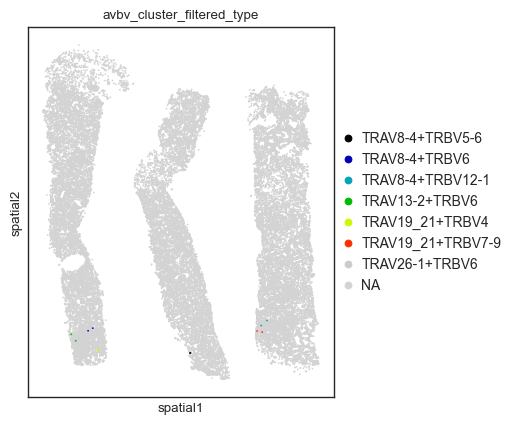

In [6]:
for sample in adata.obs["sample"].unique()[7::]:
    ad_sub = adata[adata.obs["sample"] == sample].copy()
    if ad_sub.obs[cc_type_key].notna().sum() == 0:
        continue
    sc.pl.spatial(
        ad_sub,
        color=[cc_type_key],
        show=True,
        spot_size=20,
        palette="nipy_spectral",
    )
    break

## Compare expanded vs other T cells

In [7]:
adata.X = adata.layers["counts"].copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
ad_t = adata[adata.obs["cell_type_l1"] == "T"].copy()
ad_t.obs["in_clonal_cluster"] = (
    ad_t.obs[cc_key].isin(ad_t.obs[cc_key].dropna().unique()).astype(str)
)

# remove trv genes
tv_genes = get_tcr_genes(ad_t)[-1]
ad_t = ad_t[:, [g for g in ad_t.var_names if g not in tv_genes]].copy()

Found 35 TRAV genes, 31 TRBV genes, 3 TRDV genes, 14 TRGV genes


In [8]:
ad_t.X = ad_t.layers["counts"].copy()
sc.pp.normalize_total(ad_t)
sc.pp.log1p(ad_t)

... storing 'avbv_cluster_filtered_type' as categorical
... storing 'in_clonal_cluster' as categorical


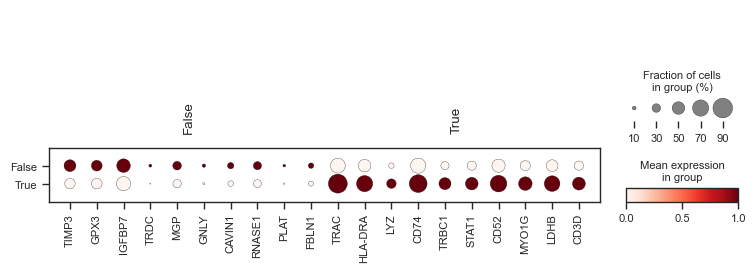

In [9]:
# differentially expressed genes between expanded and other T cells
sc.tl.rank_genes_groups(
    ad_t, groupby="in_clonal_cluster", method="wilcoxon", use_raw=False
)
sc.pl.rank_genes_groups_dotplot(
    ad_t, groupby="in_clonal_cluster", standard_scale="var", n_genes=10
)

In [10]:
de_df = sc.get.rank_genes_groups_df(ad_t, group="True").set_index("names")
de_df

,scores,logfoldchanges,pvals,pvals_adj
names,,,,
TRAC,7.740285,0.692706,9.919439e-15,3.451965e-12
HLA-DRA,5.248955,0.507578,1.529644e-07,2.214296e-05
LYZ,5.125118,0.908315,2.973509e-07,2.214296e-05
CD74,5.119307,0.457590,3.066603e-07,2.214296e-05
TRBC1,5.112368,0.681864,3.181459e-07,2.214296e-05
...,...,...,...,...
MGP,-1.514660,-0.521496,1.298584e-01,7.061051e-01
TRDC,-1.610419,-2.194379,1.073065e-01,6.223778e-01
IGFBP7,-1.772452,-0.263055,7.631953e-02,5.011169e-01


In [11]:
log2fc_cutoff = 0.0
pvalue_cutoff = 0.05
mask_1 = de_df["pvals_adj"] < pvalue_cutoff
mask_2 = de_df["logfoldchanges"] > log2fc_cutoff
# mask_3 = de_df["logfoldchanges"] < -log2fc_cutoff
mask = mask_1 & mask_2
print("\n".join(de_df.loc[mask].index.tolist()))

TRAC
HLA-DRA
LYZ
CD74
TRBC1
STAT1
CD52
MYO1G
LDHB
CD3D
SELL
TRBC2
SRGN
CD2
CD4
PTPRC
CD3G
TIMP1
CORO1A
CCR7


In [12]:
de_df.to_csv("results/revision/degs_clustered_vs_other_tcells.csv")

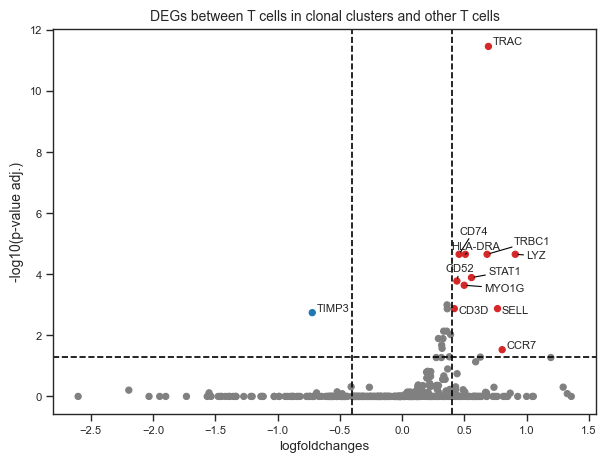

In [14]:
# volcano plot
sns.set_theme(style="ticks", context="paper")
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
dc.pl.volcano(de_df, x="logfoldchanges", y="pvals_adj", ax=ax, top=15, thr_stat=0.4)
# ax.set_xlim(-5, 5)
ax.set_title("DEGs between T cells in clonal clusters and other T cells", fontsize=10)
ax.tick_params(axis="both", labelsize=8)
ax.set_ylabel("-log10(p-value adj.)", fontsize=10)

for t in ax.texts:
    t.set_fontsize(8)


plt.savefig(
    os.path.join(figure_dir, "volcano_clonal_clusters_vs_other_tcells.pdf"),
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

In [14]:
ad_t.obs["group"] = "no-clonal-cluster"
ad_t.obs.loc[ad_t.obs["in_clonal_cluster"] == "True", "group"] = "clonal-cluster"

# sort by group
ad_t = ad_t[ad_t.obs.sort_values("group").index].copy()

In [15]:
ad_t.obs["group"]

lglnfkdh-1output-XETG00088__0029041__Region_8__20240719__095642       clonal-cluster
anpbcpop-1output-XETG00088__0029041__Region_7__20240719__095642       clonal-cluster
anpjnbmg-1output-XETG00088__0029041__Region_7__20240719__095642       clonal-cluster
chpkaaoa-1output-XETG00088__0029040__Region_5__20240719__095642       clonal-cluster
chlfghgb-1output-XETG00088__0029040__Region_5__20240719__095642       clonal-cluster
                                                                         ...        
midooknf-1output-XETG00088__0029041__Region_5__20240719__095642    no-clonal-cluster
midokpie-1output-XETG00088__0029041__Region_5__20240719__095642    no-clonal-cluster
micojpdk-1output-XETG00088__0029041__Region_5__20240719__095642    no-clonal-cluster
miiajmgg-1output-XETG00088__0029041__Region_5__20240719__095642    no-clonal-cluster
ojchajln-1output-XETG00088__0029040__Region_5__20240719__095642    no-clonal-cluster
Name: group, Length: 19621, dtype: object

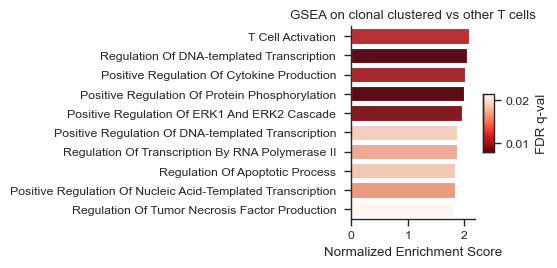

In [16]:
import gseapy as gp

# NOTE: To speed up, use gp.prerank instead with your own ranked list.
res = gp.gsea(
    data=ad_t.to_df().T,  # row -> genes, column-> samples
    gene_sets="GO_Biological_Process_2023",
    cls=ad_t.obs.group,
    permutation_num=1000,
    permutation_type="phenotype",
    outdir=None,
    method="s2n",  # signal_to_noise
    threads=16,
    # ascending=True,
)

plot_df = res.res2d.copy()
plot_df["Term"] = plot_df["Term"].str.split(r"\(").str[0]
plot_df = plot_df.head(10)

# plot as barplot
sns.set_theme(style="ticks", context="paper")
fig, ax = plt.subplots(1, 1, figsize=(2, 2.5))

sig_col = "FDR q-val"

sns.barplot(x="NES", y="Term", hue=sig_col, data=plot_df, ax=ax, palette="Reds_r")
ax.get_legend().remove()

norm = plt.Normalize(plot_df[sig_col].min(), plot_df[sig_col].max())
sm = plt.cm.ScalarMappable(cmap="Reds_r", norm=norm)
cbar = plt.colorbar(sm, ax=ax, aspect=5, shrink=0.3, label=sig_col)

ax.set_title("GSEA on clonal clustered vs other T cells")
ax.set_xlabel("Normalized Enrichment Score")
ax.set_ylabel("")
sns.despine()

plt.savefig(
    os.path.join(figure_dir, "gsea_clonal_vs_other_tcells.pdf"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [17]:
de_df_filtered = de_df[de_df["pvals_adj"] < 0.05]
de_df_filtered = de_df_filtered[de_df_filtered["logfoldchanges"].abs() > 0.4]
de_df_filtered.index.tolist()

['TRAC',
 'HLA-DRA',
 'LYZ',
 'CD74',
 'TRBC1',
 'STAT1',
 'CD52',
 'MYO1G',
 'CD3D',
 'SELL',
 'CCR7',
 'TIMP3']

In [18]:
de_genes = de_df[de_df["pvals"] < 0.05].index.tolist()
[g for g in ["STMN1", "PCNA", "CD69", "ITGAE"] if g in de_genes]

['CD69']

In [19]:
# de_df[de_df["pvals"] < 0.05]

... storing 'group' as categorical


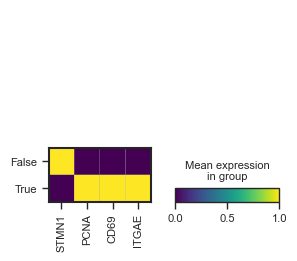

In [20]:
sc.pl.matrixplot(
    ad_t,
    var_names=["STMN1", "PCNA", "CD69", "ITGAE"],
    groupby="in_clonal_cluster",
    standard_scale="var",
    show=True,
)

For the gene CD69, the p-value is 0.0079678463860439


/tmp/ipykernel_3589484/757631759.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["other\nT cells", "in clonal\ncluster"])


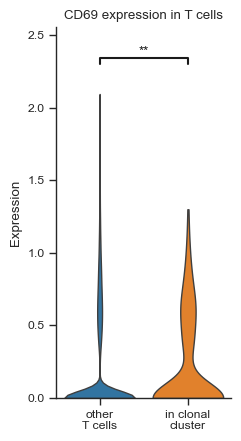

For the gene PCNA, the p-value is 0.011137970933182417


/tmp/ipykernel_3589484/757631759.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["other\nT cells", "in clonal\ncluster"])


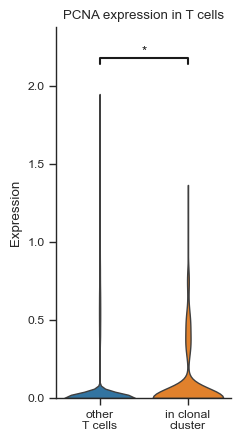

In [21]:
genes = [
    # "STMN1",
    "CD69",
    "PCNA",
    # "ITGAE",
]

for gene in genes:
    # Extract expression values and grouping labels
    expr = ad_t[:, gene].X.toarray().flatten()  # adjust if needed for sparse matrices
    labels = ad_t.obs["in_clonal_cluster"]

    group1 = expr[labels == "True"]
    group2 = expr[labels == "False"]

    # Perform Mann-Whitney U test
    stat, p_value = stats.mannwhitneyu(
        group1, group2, alternative="two-sided", method="asymptotic"
    )

    # Convert p-value to star notation
    if p_value < 0.001:
        stars = "***"
    elif p_value < 0.01:
        stars = "**"
    elif p_value < 0.05:
        stars = "*"
    else:
        stars = "ns"
    print(f"For the gene {gene}, the p-value is {p_value}")

    # Create violin plot
    sns.set_theme(style="ticks", context="paper")
    fig, ax = plt.subplots(1, 1, figsize=(2.5, 4.5))

    plot_df = ad_t.obs[["in_clonal_cluster"]].copy()
    plot_df.loc[:, gene] = expr
    plot_df = pd.melt(plot_df, id_vars=["in_clonal_cluster"], value_vars=[gene])
    sns.violinplot(
        data=plot_df,
        x="in_clonal_cluster",
        y="value",
        hue="in_clonal_cluster",
        ax=ax,
        inner=None,
        palette="tab10",
        cut=0,
    )

    # Determine positions for annotation (assuming two groups at x=0 and x=1)
    # Adjust the y-offset based on your data range:
    y_max = np.max(expr)
    y = y_max + 0.1 * (y_max)  # starting height of the line
    h = 0.02 * (y_max)  # height of the significance bar

    x1, x2 = 0, 1
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.5, c="k")
    ax.text((x1 + x2) * 0.5, y + h, stars, ha="center", va="bottom", color="k")

    # Add a bit more space at the top of the plot for significance annotation
    ax.set_ylim(top=y + h + 0.1 * y_max, bottom=0)

    ax.set_xlabel("")
    ax.set_ylabel("Expression")
    ax.set_title(f"{gene} expression in T cells")

    ax.set_xticklabels(["other\nT cells", "in clonal\ncluster"])

    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig(
        os.path.join(figure_dir, f"tcell_de_violin_{gene}.pdf"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

## check t cell subtype composition of clonal clusters compared to the rest

In [22]:
color_dict = {
    "CD4+": (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
    "CD8+": (1.0, 0.4980392156862745, 0.054901960784313725),
    "NK/NKT": (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
    "Tregs": (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
    "gdT": (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
    "MAIT": (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
}

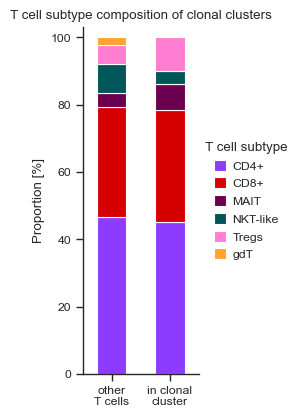

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(1.5, 4.5))
data = (
    ad_t.obs.groupby("in_clonal_cluster", observed=True)["cell_type_l2"]
    .value_counts(normalize=True)
    .unstack()
    * 100
)
data.plot(kind="bar", stacked=True, ax=ax, color=colors_new)
ax.set_xlabel("Clonal cluster")
ax.set_ylabel("Proportion [%]")
ax.set_title("T cell subtype composition of clonal clusters")
sns.despine(ax=ax)
# roate xlabels
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center")

# set xticklabels
ax.set_xlabel("")
ax.legend(
    title="T cell subtype",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False,
)

ax.set_xticklabels(["other\nT cells", "in clonal\ncluster"])

ax.set_ylim(0, 103)

# plt.tight_layout()
plt.savefig(
    os.path.join(figure_dir, "tcell_subtype_composition_clonal_clusters.pdf"),
    dpi=300,
    bbox_inches="tight",
)